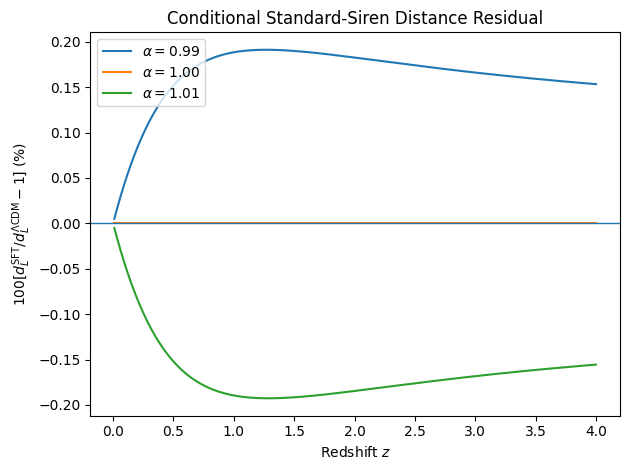

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ------------------------------------------------------------
# Paper I baseline cosmological parameters
# ------------------------------------------------------------

Omega_m0 = 0.31500
Omega_r0 = 9.034e-5
Omega_DE0 = 0.68491

# ------------------------------------------------------------
# Expansion functions
# ------------------------------------------------------------

def E_LCDM(z):
    return np.sqrt(
        Omega_m0 * (1.0 + z)**3
        + Omega_r0 * (1.0 + z)**4
        + Omega_DE0
    )

def E_SFT(z, alpha):
    return np.sqrt(
        Omega_m0 * (1.0 + z)**3
        + Omega_r0 * (1.0 + z)**4
        + Omega_DE0 * (1.0 + z)**(-3.0 * (1.0 - alpha))
    )

# H0 and c cancel in the luminosity-distance ratio,
# so dimensionless comoving-distance integrals are sufficient.

def distance_integral(z, E_function):
    return quad(
        lambda zp: 1.0 / E_function(zp),
        0.0,
        z,
        epsabs=1e-11,
        epsrel=1e-11
    )[0]

def delta_siren(z, alpha):
    d_sft = distance_integral(
        z,
        lambda zp: E_SFT(zp, alpha)
    )

    d_lcdm = distance_integral(
        z,
        E_LCDM
    )

    return d_sft / d_lcdm - 1.0


# ------------------------------------------------------------
# Numerical grid
# ------------------------------------------------------------

z_values = np.linspace(0.01, 4.0, 300)

alphas = [0.99, 1.00, 1.01]

for alpha in alphas:
    if alpha == 1.00:
        residual = np.zeros_like(z_values)
    else:
        residual = np.array([
            100.0 * delta_siren(z, alpha)
            for z in z_values
        ])

    plt.plot(
        z_values,
        residual,
        label=fr'$\alpha={alpha:.2f}$'
    )

plt.axhline(0.0, linewidth=1)

plt.xlabel(r'Redshift $z$')
plt.ylabel(
    r'$100[d_L^{\rm SFT}/d_L^{\Lambda{\rm CDM}}-1]\;(\%)$'
)
plt.title(
    'Conditional Standard-Siren Distance Residual'
)
plt.legend()
plt.tight_layout()

plt.savefig(
    'standard_siren_SFT_LCDM_residual.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

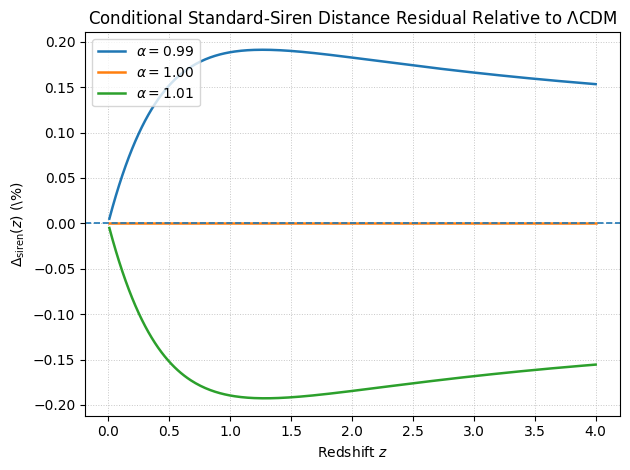

In [3]:
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

z_values = np.linspace(0.01, 4.0, 300)

alphas = [0.99, 1.00, 1.01]

for alpha in alphas:
    if alpha == 1.00:
        residual = np.zeros_like(z_values)
    else:
        residual = np.array([
            100.0 * delta_siren(z, alpha)
            for z in z_values
        ])

    plt.plot(
        z_values,
        residual,
        linewidth=1.8,
        label=fr'$\alpha={alpha:.2f}$'
    )

# Zero-reference line
plt.axhline(
    0.0,
    linestyle='--',
    linewidth=1.2
)

# Horizontal and vertical grid lines
plt.grid(
    True,
    which='major',
    linestyle=':',
    linewidth=0.7,
    alpha=0.7
)

plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$\Delta_{\rm siren}(z)$ (\%)')

plt.title(
    r'Conditional Standard-Siren Distance Residual Relative to $\Lambda$CDM'
)

plt.legend()

plt.tight_layout()

plt.savefig(
    'standard_siren_SFT_LCDM_residual.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()